In [ ]:
# Q1 Loading the dataaset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv('train.txt', sep=';', names=['text', 'emotions'])

In [ ]:
# Dataset load
df = pd.read_csv('train.txt', sep=';', names=['text', 'emotions'])
df.head(10)

,text,emotions
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
5,ive been feeling a little burdened lately wasn...,sadness
6,ive been taking or milligrams or times recomme...,surprise
7,i feel as confused about life as a teenager or...,fear
8,i have been with petronas for years i feel tha...,joy
9,i feel romantic too,love


In [ ]:
df.shape

(16000, 2)

In [ ]:
# Check missing values
df.isnull().sum()

,0
text,0
emotions,0


In [ ]:
# Q2
# Unique emotion labels
from sklearn.preprocessing import LabelEncoder
print("Unique Emotions:", df['emotions'].unique())

Unique Emotions: ['sadness' 'anger' 'love' 'surprise' 'fear' 'joy']


In [ ]:
# LabelEncoding
le = LabelEncoder()
df['encoded_emotions'] = le.fit_transform(df['emotions'])

In [ ]:
# Mapping dictionary
emotion_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print("\nEmotion Mapping Dictionary:", emotion_mapping)

df.head()


Emotion Mapping Dictionary: {'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5}


,text,emotions,encoded_emotions
0,i didnt feel humiliated,sadness,4
1,i can go from feeling so hopeless to so damned...,sadness,4
2,im grabbing a minute to post i feel greedy wrong,anger,0
3,i am ever feeling nostalgic about the fireplac...,love,3
4,i am feeling grouchy,anger,0


In [ ]:
# Q3 Lowercasing
# Lowercasing the text
df['text'] = df['text'].apply(lambda x: x.lower())

In [ ]:
df[['text']].head(5)

,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy


Note on Lowercasing in NLP:
Lowercasing standardizes text so that words like "Happy" and "happy" are treated as the exact same token, reducing vocabulary size and redundant features.

In [ ]:
# Q4 Removing punctuation
import string

def remove_punc(txt):
    return txt.translate(str.maketrans('', '', string.punctuation))

df['text'] = df['text'].apply(remove_punc)

# Show 5 examples
df[['text']].head(5)

,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy


In [ ]:
# Q5 Removing Numbers
def remove_number(txt):
    new = ""
    for i in txt:
        if not i.isdigit():
            new = new + i
    return new

df['text'] = df['text'].apply(remove_number)

# Show examples
df[['text']].head(5)

,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy


In [ ]:
# Q6 Removing Emojis & Special characters
def remove_emojis(txt):
    new = ""
    for i in txt:
        if i.isascii():
            new = new + i
    return new

df['text'] = df['text'].apply(remove_emojis)

# Show cleaned text samples
df[['text']].head(5)

,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy


In [ ]:
# Q7
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(txt):
    words = txt.split()
    cleaned = []
    for i in words:
        if i not in stop_words:
            cleaned.append(i)
    return ' '.join(cleaned)

df['text'] = df['text'].apply(remove_stopwords)

# Show 5 cleaned text samples
df[['text']].head(5)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,text
0,didnt feel humiliated
1,go feeling hopeless damned hopeful around some...
2,im grabbing minute post feel greedy wrong
3,ever feeling nostalgic fireplace know still pr...
4,feeling grouchy


In [26]:
# Q8. Complete Text Cleaning Pipeline

# Single function all combining Q3 to Q7 steps
def complete_cleaning_pipeline(text):
    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = "".join([char for char in text if not char.isdigit()])

    # Remove non-ascii / emojis
    text = "".join([char for char in text if char.isascii()])

    # Remove stopwords
    words = text.split()
    clean_words = [w for w in words if w not in stop_words]

    return " ".join(clean_words)


# Apply the pipeline on the original text column
df["cleaned_text"] = df["text"].apply(complete_cleaning_pipeline)

# Display the original text and cleaned side by side for 10 samples.
df[["text", "cleaned_text"]].head(10)

,text,cleaned_text
0,i didnt feel humiliated,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,im grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,feeling grouchy
5,ive been feeling a little burdened lately wasn...,ive feeling little burdened lately wasnt sure
6,ive been taking or milligrams or times recomme...,ive taking milligrams times recommended amount...
7,i feel as confused about life as a teenager or...,feel confused life teenager jaded year old man
8,i have been with petronas for years i feel tha...,petronas years feel petronas performed well ma...
9,i feel romantic too,feel romantic


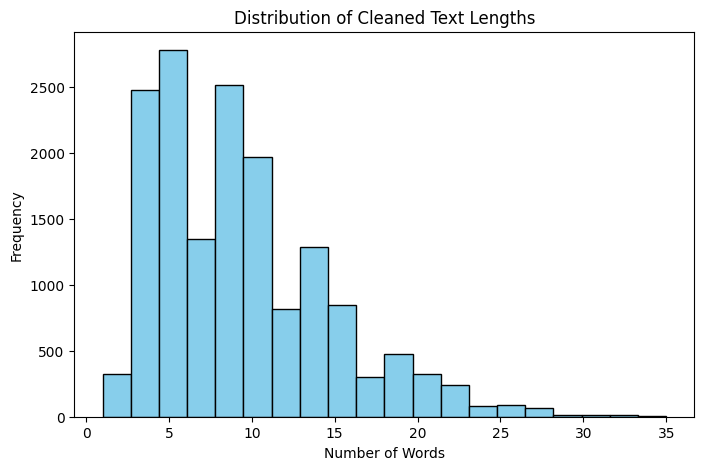

Average text length: 9.35
Minimum text length: 1
Maximum text length: 35


In [ ]:
# Q9
# Complete cleaning function
def clean_text(txt):
    txt = txt.lower()
    txt = txt.translate(str.maketrans('', '', string.punctuation))
    txt = ''.join([i for i in txt if not i.isdigit() and i.isascii()])
    words = [w for w in txt.split() if w not in stop_words]
    return ' '.join(words)

# Create cleaned_text column first
df['cleaned_text'] = df['text'].apply(clean_text)

# Now calculate word length
df['text_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(df['text_length'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Cleaned Text Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

# Print statistics
print("Average text length:", round(df['text_length'].mean(), 2))
print("Minimum text length:", df['text_length'].min())
print("Maximum text length:", df['text_length'].max())

Observations:
1. After removing stopwords, punctuation, and numbers, the overall word count in each sentence has reduced significantly.
2. Most of the cleaned sentences have a word length ranging between 5 to 15 words.
3. The minimum length is very small (some sentences reduced to 1 or 2 core words), while the maximum length dropped compared to the raw text.
4. The dataset is now concise and contains only meaningful words, which will help the NLP model train faster and perform better.
5.

In [ ]:
# Q10. Mini Project - Full Preprocessing Pipeline

import numpy as np
import pandas as pd
import string
import nltk
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


# Text cleaning function combining all steps
def clean_text_pipeline(text):
    # Lowercasing
    text = text.lower()

    # Removing punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Removing digits
    text = "".join([char for char in text if not char.isdigit()])

    # Removing non-ASCII / emojis
    text = "".join([char for char in text if char.isascii()])

    # Removing stopwords
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]

    return " ".join(filtered_words)


# 1. Load the data
df = pd.read_csv("train.txt", sep=";", names=["text", "emotions"])

# 2. Encode the emotion labels
encoder = LabelEncoder()
df["encoded_emotions"] = encoder.fit_transform(df["emotions"])

# 3. Perform complete text cleaning
df["cleaned_text"] = df["text"].apply(clean_text_pipeline)

# 4. Save the cleaned dataset as cleaned_emotions.csv
final_data = df[["cleaned_text", "encoded_emotions"]]
final_data.to_csv("cleaned_emotions.csv", index=False)
print("File successfully saved as cleaned_emotions.csv")

# 5. Show value counts of each emotion
print("\nEmotion Value Counts:")
print(df["emotions"].value_counts())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


File successfully saved as cleaned_emotions.csv

Emotion Value Counts:
emotions
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64
